In [58]:
import pandas as pd
import numpy as np
import joblib
import model_explain_functions as explain
import qsar_functions as qsar
from importlib import reload

In [164]:
reload(explain)

<module 'model_explain_functions' from 'c:\\Users\\anamj\\Documents\\DSSCDB_HS\\DSSCDB\\model_explain_functions.py'>

In [6]:
def make_oof_summary(preds_df: pd.DataFrame,
                     splits: list[tuple[pd.Index, pd.Index]],
                     col_prefix: str,
                     y_true: pd.Series | None = None,
                     ddof: int = 1) -> pd.DataFrame:
    """
    Build a per-molecule summary from out-of-fold (test) predictions.

    Parameters
    ----------
    preds_df : DataFrame
        Must have index = molecule IDs and one column per split named
        f"{col_prefix}{i:02d}" (e.g., "pred_mlp_median_03").
    splits : list of (train_idx, test_idx)
        Each element is a tuple of pd.Index of labels for train/test.
    col_prefix : str
        Prefix for prediction columns, ending with underscore, e.g. "pred_mlp_median_".
    y_true : optional Series
        If provided, added as the first column (aligned by index).
    ddof : int
        Degrees of freedom for std (1 gives sample std; 0 gives population std).

    Returns
    -------
    DataFrame with columns:
        ['y_true' (optional), 'test_count', 'oof_pred_mean', 'oof_pred_std']
    """
    idx_all = preds_df.index
    counts = pd.Series(0, index=idx_all, dtype=int)
    sum_pred = pd.Series(0.0, index=idx_all, dtype=float)
    sumsq_pred = pd.Series(0.0, index=idx_all, dtype=float)

    for i, (_tr_idx, te_idx) in enumerate(splits):
        col = f"{col_prefix}{i:02d}"
        if col not in preds_df.columns:
            raise KeyError(f"Missing prediction column '{col}' in preds_df.")
        p = preds_df.loc[te_idx, col].astype(float)

        counts.loc[te_idx]      += 1
        sum_pred.loc[te_idx]    += p
        sumsq_pred.loc[te_idx]  += p * p

    # Mean only where count>0
    mean = pd.Series(np.nan, index=idx_all, dtype=float)
    mask_c = counts > 0
    mean.loc[mask_c] = (sum_pred.loc[mask_c] / counts.loc[mask_c]).values

    # Std (NaN for count < 2)
    std = pd.Series(np.nan, index=idx_all, dtype=float)
    mask_s = counts > ddof
    # variance = (Σx^2 - n*mean^2) / (n - ddof)
    var_num = sumsq_pred.loc[mask_s] - counts.loc[mask_s] * (mean.loc[mask_s] ** 2)
    std.loc[mask_s] = np.sqrt(var_num / (counts.loc[mask_s] - ddof))

    out = pd.DataFrame(index=idx_all)
    if y_true is not None:
        out["y_true"] = y_true.reindex(idx_all)
    out["test_count"]   = counts
    out["oof_pred_mean"] = mean
    out["oof_pred_std"]  = std
    out["abs_error"] = abs(out["y_true"] - out["oof_pred_mean"])
    return out


In [2]:
dye_device_descs = pd.read_csv('Data/dye_device_fp_not_imputed.csv', index_col=0)
smiles_df = pd.read_csv('Data/cleaned_SMILES.csv', index_col=0)
pce = smiles_df['PCE']
splits = joblib.load("models/splits_indices.joblib")  # list of (pd.Index, pd.Index)
preds_df = pd.read_csv("models/raw_predictions.csv", index_col=0) 

In [7]:
# Build summary for one model/imputation combo
summary_rf = make_oof_summary(
    preds_df=preds_df,
    splits=splits,
    col_prefix="pred_rf_KNN_", 
    y_true=pce,                   # optional
    ddof=1                           # sample std
)
summary_rf

,y_true,test_count,oof_pred_mean,oof_pred_std,abs_error
0,5.19,22,4.800131,0.166651,0.389869
1,2.60,20,4.570274,0.583709,1.970274
2,3.10,31,4.017110,0.723650,0.917110
3,2.20,25,4.885043,0.145242,2.685043
4,5.00,22,5.407360,0.298751,0.407360
...,...,...,...,...,...
4421,8.79,20,8.124275,0.223571,0.665725
4422,4.52,24,4.492971,0.126212,0.027029
4423,6.09,18,5.532972,0.140082,0.557028
4424,5.65,19,5.605128,0.150506,0.044872


<Axes: xlabel='oof_pred_std', ylabel='abs_error'>

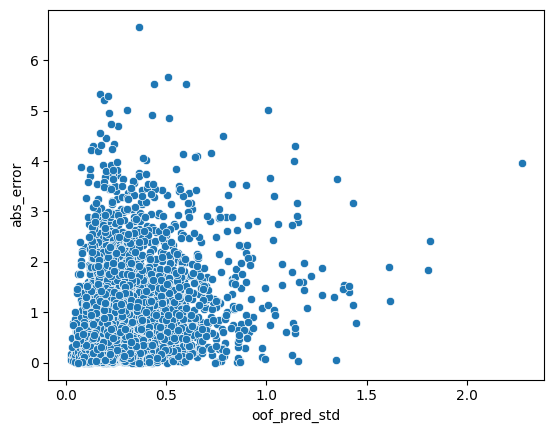

In [8]:
import seaborn as sns
sns.scatterplot(summary_rf, x='oof_pred_std', y='abs_error')

In [3]:
smiles_test = smiles_df['SMILES'].loc[splits[0][1]]
smiles_test

383     CCCCCCN1c2ccc(cc2S(=O)(=O)c2c1ccc(c2)c1ccc(s1)...
2284    CCCCCCC1(CCCCCC)c2cc(sc2c2c1cc(s2)c1ccc2c(c1)[...
3448    N#C/C(=C\\c1ccc(s1)/C/1=C/2\\C=CC(=N2)/C(=c/2\...
1877    CCCCCCCCOc1c(OCCCCCCCC)c(c2ccc(s2)N(c2ccccc2)c...
2462               OC(=O)C=Cc1ccc(cc1)N(c1ccccc1)c1ccccc1
                              ...                        
1005    CCCCCCOc1ccc(cc1)C1(c2ccc(cc2)OCCCCCC)c2cc3c4s...
4131    CCN1c2ccccc2C(/C/1=C/C=C/1\\SC(=S)N(C1=O)CC(=O...
692     CCCCCCc1cc(sc1/C=C(\\C(=O)O)/C#N)c1sc2c(c1)c1n...
2345    CCCCCCCCOc1ccc(cc1)N(c1ccc(cc1)OCCCCCCCC)c1ccc...
289     CCCCCCCCN1c2ccc(cc2Sc2c1ccc(c2)c1ccc(s1)/C=C(/...
Name: SMILES, Length: 886, dtype: object

In [4]:

from rdkit import Chem
from rdkit.Chem import rdMolDescriptors as Descriptors
import pandas as pd
from collections import Counter
from rdkit.Chem.Scaffolds import MurckoScaffold


# ---------- Helpers ----------
def smarts(s):
    m = Chem.MolFromSmarts(s)
    if m is None:
        raise ValueError(f"Invalid SMARTS: {s}")
    return m

def count_pyrrolic_like_N(mol):
    """
    Proxy for porphyrinoids: count aromatic 5-member rings containing an aromatic N.
    Porphyrins usually have 4 such rings.
    """
    ri = mol.GetRingInfo()
    count = 0
    for ring in ri.AtomRings():
        if len(ring) != 5:
            continue
        if not all(mol.GetAtomWithIdx(i).GetIsAromatic() for i in ring):
            continue
        if any(mol.GetAtomWithIdx(i).GetAtomicNum() == 7 and mol.GetAtomWithIdx(i).GetIsAromatic()
               for i in ring):
            count += 1
    return count

# ---------- SMARTS library (broadened) ----------
PATTERNS = {
    # RUTHENIUM
    "ruthenium": [
        smarts("[Ru]"),
    ],

    # PORPHYRIN -> heuristic below

    # SQUARAINE:
    #  - core cyclobutenedione (squaric acid) ring
    #  - allow exocyclic C=C attachment sites (typical squaraine dyes)
    "squaraine": [
        smarts("O=C1C(=O)C(=O)C(=O)1"),                # fully carbonylated
        smarts("O=C1C(=O)C(O)=C(=O)1"),                # enol
        smarts("O=C1C(=O)C([O-])=C(=O)1"),             # enolate
        smarts("O=C1C(=O)C(=C*)C(=O)1"),               # exocyclic vinyl sites
        smarts("O=C1C(=*)C(=O)C(=O)1"),                # more permissive exocyclic *
        smarts("C1(=O)C(=O)C(=O)C(=O)1"),
    ],

    # PHENOTHIAZINE:
    #  - tricyclic system containing N and S in central ring
    #  - include sulfoxide/sulfone derivatives common in dyes
    "phenothiazine": [
        smarts("c1ccc2nc3ccccc3sc2c1"),
        smarts("c1ccc2sc3ccccn3c2c1"),
        smarts("[nH]1c2ccccc2sc3ccccc13"),
        smarts("c1ccc2nc3ccccc3s(=O)c2c1"),            # sulfoxide
        smarts("c1ccc2nc3ccccc3s(=O)(=O)c2c1"),        # sulfone
        smarts("c1ccc2c(c1)Nc1ccccc1S2"),   # matches your misc scaffold
        smarts("c1ccc2nc3ccccc3sc2c1"),
    ],

    # CARBAZOLE
    "carbazole": [
        smarts("c1ccc2c(c1)[nH]c3ccccc23"),
        smarts("n1c2ccccc2c3ccccc13"),
        smarts("[nH]1c2ccccc2c3ccccc13"),
    ],

    # TRIPHENYLAMINE (stricter; last in priority)
    #  N (non-carbonyl, non-quaternary), NOT in a ring, single-bonded to 3 aromatic carbons
    "triphenylamine": [
        smarts("[N;X3;H0;!$(*=O);!$([N+]);!R]([c;a])([c;a])[c;a]"),
    ],

    # INDOLINE (hydrogenated indole; 5-member N ring fused to benzene; allow tertiary/secondary)
    "indoline": [
        smarts("[NH]1Cc2ccccc2C1"),                    # secondary
        smarts("[N;X3]1Cc2ccccc2CC1"),                 # tertiary/saturated
        smarts("c1ccc2NCCCc2c1"),                      # compact fused motif
        smarts("c1cccc2NCCCc12"),                      # variant
        smarts("c1cc2CCCCN2c1"),                       # relaxed fused variant
    ],

    # COUMARIN (2H-chromen-2-one; very compact core)
    "coumarin": [
        smarts("O=c1occc2ccccc12"),                    # minimal coumarin core
        smarts("O=C1Oc2ccccc2C=C1"),                   # variant
        smarts("O=C1OC=CC2=CC=CC=C12"),                # classic
        smarts("O=C1C=CC(=O)Oc2ccccc12"), 
    ],
}

FAMILY_PRIORITY = [
    "ruthenium",
    "porphyrin",       # via heuristic
    "squaraine",
    "phenothiazine",
    "carbazole",
    "indoline",
    "coumarin",
    "triphenylamine",  # keep last so it doesn't swallow others
]

PRETTY_NAME = {
    "ruthenium": "ruthenium",
    "porphyrin": "porphyrin",
    "squaraine": "squaraine",
    "phenothiazine": "phenotiazine",  # per your label
    "carbazole": "carbazole",
    "triphenylamine": "triphenylamine",
    "indoline": "indoline",
    "coumarin": "coumarin",
    "misc": "miscellaneous",
}

def classify_smiles(smiles, return_all=False):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return ("miscellaneous" if not return_all else ["miscellaneous"])

    hits = set()

    # Porphyrin heuristic
    try:
        if count_pyrrolic_like_N(mol) >= 4:
            hits.add("porphyrin")
    except Exception:
        pass

    # Substructure matches
    for fam, patt_list in PATTERNS.items():
        for patt in patt_list:
            if mol.HasSubstructMatch(patt):
                hits.add(fam)
                break

    if not hits:
        return ("miscellaneous" if not return_all else ["miscellaneous"])

    for fam in FAMILY_PRIORITY:
        if fam in hits:
            primary = PRETTY_NAME.get(fam, fam)
            break

    if return_all:
        ordered = []
        for fam in FAMILY_PRIORITY:
            if fam in hits:
                ordered.append(PRETTY_NAME.get(fam, fam))
        for fam in sorted(hits - set(FAMILY_PRIORITY)):
            ordered.append(PRETTY_NAME.get(fam, fam))
        return ordered
    else:
        return primary

def tag_dataframe(df, smiles_col="smiles", with_all_matches=True):
    df = df.copy()
    df["primary_family"] = df[smiles_col].apply(lambda s: classify_smiles(s, return_all=False))
    if with_all_matches:
        df["all_families"] = df[smiles_col].apply(lambda s: classify_smiles(s, return_all=True))
    return df

# ---------- Debug utilities ----------
def debug_family_hits(df, smiles_col="smiles", sample_n=5):
    """Print raw substructure hits per family (ignores priority)."""
    fam2hits = {k: [] for k in PATTERNS.keys()}
    fam2hits["porphyrin"] = []
    for s in df[smiles_col]:
        m = Chem.MolFromSmiles(s)
        if m is None:
            continue
        if count_pyrrolic_like_N(m) >= 4:
            fam2hits["porphyrin"].append(s)
        for fam, patt_list in PATTERNS.items():
            for patt in patt_list:
                if m.HasSubstructMatch(patt):
                    fam2hits[fam].append(s)
                    break

    print("== Raw substructure matches (per family) ==")
    for fam, lst in fam2hits.items():
        print(f"{fam:15s}  {len(lst):4d}")
        for ex in lst[:sample_n]:
            print("   ", ex)
        if len(lst) > sample_n:
            print("   ...")
    print("===========================================")

def show_common_scaffolds_in_misc(df, smiles_col="smiles", top_k=15):
    """Show the most common Murcko scaffolds inside 'miscellaneous' to discover missed motifs."""
    misc = df[df["primary_family"] == "miscellaneous"][smiles_col].tolist()
    scaffs = []
    for s in misc:
        m = Chem.MolFromSmiles(s)
        if m:
            scaffs.append(Chem.MolToSmiles(MurckoScaffold.GetScaffoldForMol(m)))
    counts = Counter(scaffs).most_common(top_k)
    print("\n== Common Murcko scaffolds in 'miscellaneous' ==")
    for smi, n in counts:
        print(f"{n:4d}  {smi}")
    print("================================================")



In [5]:
out = tag_dataframe(pd.DataFrame(smiles_test), smiles_col="SMILES", with_all_matches=True)
out['primary_family'].value_counts()

primary_family
triphenylamine    319
miscellaneous     243
phenotiazine       94
ruthenium          93
carbazole          92
indoline           35
porphyrin          10
Name: count, dtype: int64

In [6]:
debug_family_hits(out, smiles_col='SMILES')

== Raw substructure matches (per family) ==
ruthenium          93
    S=C=N[Ru]12(N=C=S)(N3C=C[C@H](C=C3C3=C[C@@H](C=CN23)C(=O)O)C(=O)O)N2C=C[C@H](C=C2C2=C[C@@H](C=CN12)C(=O)O)C(=O)O
    O=C([O-])C1CCN2C(C1)C1CC(C(=O)O)CCN1[Ru]21(N=C=S)(N=C=S)N2CCC(C(=O)[O-])CC2C2CC(C(=O)O)CCN21
    S=C=N[Ru]12(N=C=S)(N3C=C[C@H](C=C3C3=C[C@@H](C=CN23)C(=O)O)C(=O)O)N2C=C[C@H](C=C2C2=C[C@@H](C=CN12)C(=O)O)C(=O)O
    O=C([O-])C1CCN2C(C1)C1CC(C(=O)O)CCN1[Ru]21(N=C=S)(N=C=S)N2CCC(C(=O)[O-])CC2C2CC(C(=O)O)CCN21
    S=C=N[Ru]12(N=C=S)(N3C=C[C@H](C=C3C3=C[C@@H](C=CN23)C(=O)O)C(=O)O)N2C=C[C@H](C=C2C2=C[C@@H](C=CN12)C(=O)O)C(=O)O
   ...
squaraine           0
phenothiazine      94
    CCCCCCN1c2ccc(cc2S(=O)(=O)c2c1ccc(c2)c1ccc(s1)/C=C(\\C(=O)O)/C#N)c1ccc(cc1)N(c1ccc(cc1)OCCCCCC)c1ccc(cc1)OCCCCCC
    CCCCCCN1c2ccc(cc2Sc2c1cccc2)/C=C(/C(=O)O)\\C#N
    CCCCN1c2ccc(cc2Sc2c1ccc(c2)c1ccc(cc1OCCCC)OCCCC)c1ccc(c2c1nsn2)c1ccc(s1)/C=C(/C(=O)O)\\C#N
    CCCCCCN1c2ccc(cc2Sc2c1ccc(c2)/C=C(\\C(=O)O)/C#N)C#Cc1ccc(cc1)C#Cc1ccc2c

In [7]:
show_common_scaffolds_in_misc(out, smiles_col="SMILES", top_k=25)


== Common Murcko scaffolds in 'miscellaneous' ==
  11  C(#Cc1ccccc1)/C1=c2\cc/c3[n]2[Zn][n]2c(ccc2/C(N(c2ccccc2)c2ccccc2)=C2/C=CC(=N2)/C=3c2ccccc2)/C(c2ccccc2)=C2/C=CC1=N2
   9  C1=C/C2=C(\c3ccccc3)c3ccc4[n]3[Zn][n]3/c(cc/c3=C(\c3ccccc3)C3=N/C(=C\4c4ccccc4)C=C3)=C(/c3ccccc3)C1=N2
   6  C(#Cc1ccccc1)/C1=C2\C=CC(=N2)/C(c2ccccc2)=c2/cc/c3[n]2[Zn][n]2c1ccc2/C(c1ccccc1)=C1/C=CC(=N1)/C=3C#Cc1ccccc1
   6  O=C1C(/C=C2/Cc3cc(-c4ccccc4)ccc3N2)=C/C1=C\C1=[NH+]c2ccccc2C1
   4  O=C1/C(=C/C2=[NH+]c3ccccc3C2)CC1/C=C1\Cc2ccccc2N1
   4  C(=C(c1ccccc1)c1ccccc1)c1ccc(N2c3ccccc3C3CCCC32)cc1
   3  c1ccc(N2c3ccc(-c4ccc(-c5cccs5)c5nsnc45)cc3C3CCCC32)cc1
   3  C(#Cc1ccccc1)C1=CC2=N/C1=C(/c1ccccc1)c1ccc3[n]1[Zn][n]1/c(cc/c1=C/2c1ccccc1)=C(/c1ccccc1)C1=N/C(=C\3c2ccccc2)C=C1
   3  C(=C(c1ccc(-c2ccccc2)cc1)c1ccc(-c2ccccc2)cc1)c1ccc(N2c3ccc(-c4ncc(-c5cccs5)c5nc(-c6ccccc6)c(-c6ccccc6)nc45)cc3C3CCCC32)cc1
   3  C1=C/C2=C/c3ccc4[n]3[Zn][n]3/c(cc/c3=C(\N(c3ccccc3)c3ccccc3)C3=N/C(=C\4c4ccccc4)C=C3)=C(/c3ccccc3)C1=N2
 

In [8]:
def probe_presence(smiles_list):
    tests = {
        "coumarin_core1": "O=C1Oc2ccccc2C=C1",
        "coumarin_core2": "O=c1occc2ccccc12",
        "squaraine_core1": "O=C1C(=O)C(=O)C(=O)1",
        "squaraine_core2": "O=C1C(=O)C(=C*)C(=O)1",
    }
    for name, patt in tests.items():
        p = smarts(patt)
        n = 0
        for s in smiles_list:
            m = Chem.MolFromSmiles(s)
            if m and m.HasSubstructMatch(p):
                n += 1
        print(f"{name:16s}: {n}")

# Example call
probe_presence(pd.DataFrame(smiles_test)["SMILES"].tolist())  # or your smiles column


coumarin_core1  : 0
coumarin_core2  : 0
squaraine_core1 : 0
squaraine_core2 : 0


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Predicted', ylabel='Measured'>)

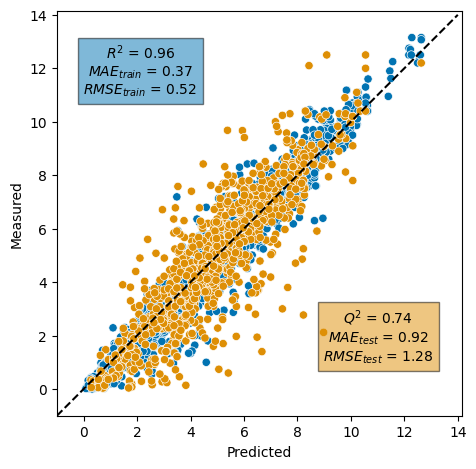

In [16]:
model_dir = 'models/rf_pipeline_KNN_0.joblib'
pipe = joblib.load(model_dir)

    # Split
X_train = dye_device_descs.loc[splits[0][0]]
X_test = dye_device_descs.loc[splits[0][1]]
y_train = pce.loc[splits[0][0]]
y_test = pce.loc[splits[0][1]]
P_test = pd.DataFrame(pipe.predict(X_test), index=X_test.index)

    #Visualization Split 0
qsar_df, train_raw, test_raw = qsar.reg_results_df(pipe, X_train, X_test, y_train, y_test)
qsar.reg_results_viz_sns(qsar_df, train_raw, test_raw, box_adjustment=0.15)

In [10]:
explanation, X_eval, P_eval = explain.get_Explanation_object(model_dir, dye_device_descs, pce, splits[0])

 99%|===================| 879/886 [02:25<00:01]        

In [140]:
# Boolean mask for the family, aligned to X_test’s index
mask_tpa = out['primary_family'].eq('triphenylamine').reindex(X_test.index).fillna(False).to_numpy()

# Slice X, y (or P_test), and the SHAP Explanation
X_test_tpa = X_test.loc[mask_tpa]
P_test_tpa = P_test.loc[mask_tpa]
expl_tpa   = explanation[mask_tpa] 

c:\Users\anamj\Documents\DSSCDB_HS\DSSCDB\model_explain_functions.py:327: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


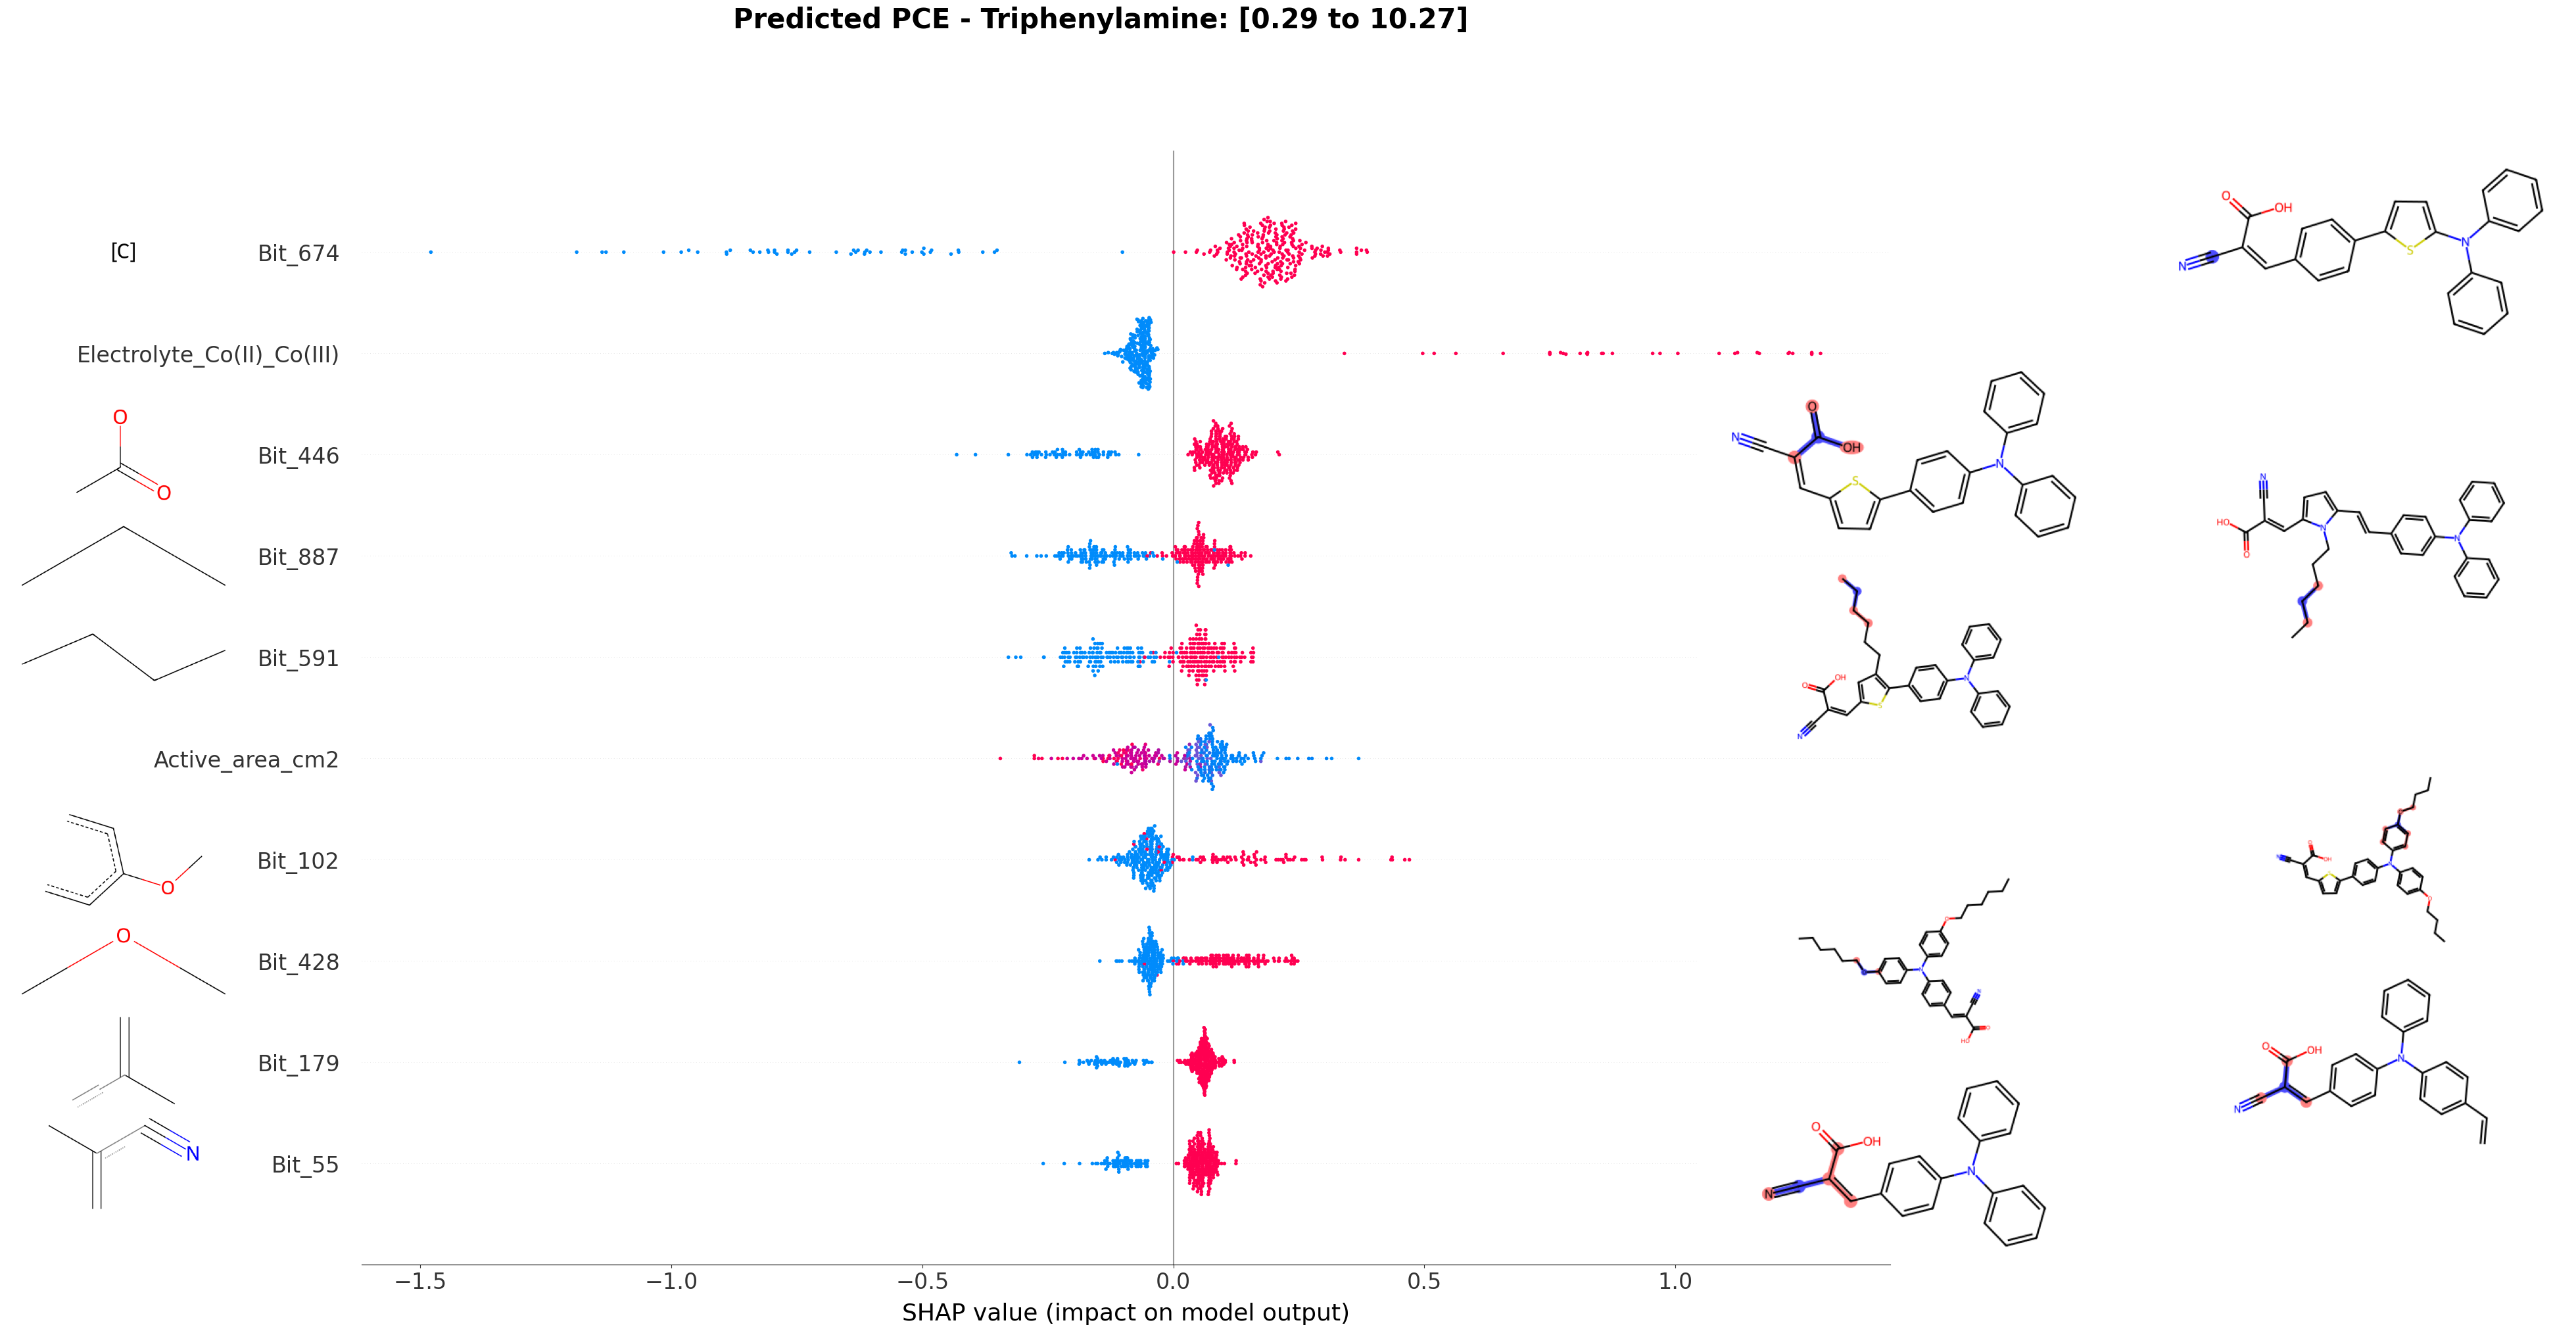

In [144]:
explain.shap_mol_fp(explanation=expl_tpa,
            X_test=X_test_tpa, 
            P_test=P_test_tpa, 
            title="Predicted PCE - Triphenylamine", 
            smiles_df=smiles_df,
            left=-1150,
            right=800,
            plot_type='dot', 
            max_display=10
)

In [145]:

# 1) boolean mask (aligned to X_test’s order)
mask_tpa = out['primary_family'].eq('phenotiazine').to_numpy()

# 2) subset everything consistently
X_test_tpa = X_test.loc[mask_tpa]
P_test_tpa = P_test.loc[mask_tpa]
smiles_tpa = smiles_df.loc[mask_tpa]

# 3) SHAP Explanation supports boolean masks (positional)
expl_tpa = explanation[mask_tpa]


c:\Users\anamj\Documents\DSSCDB_HS\DSSCDB\model_explain_functions.py:327: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


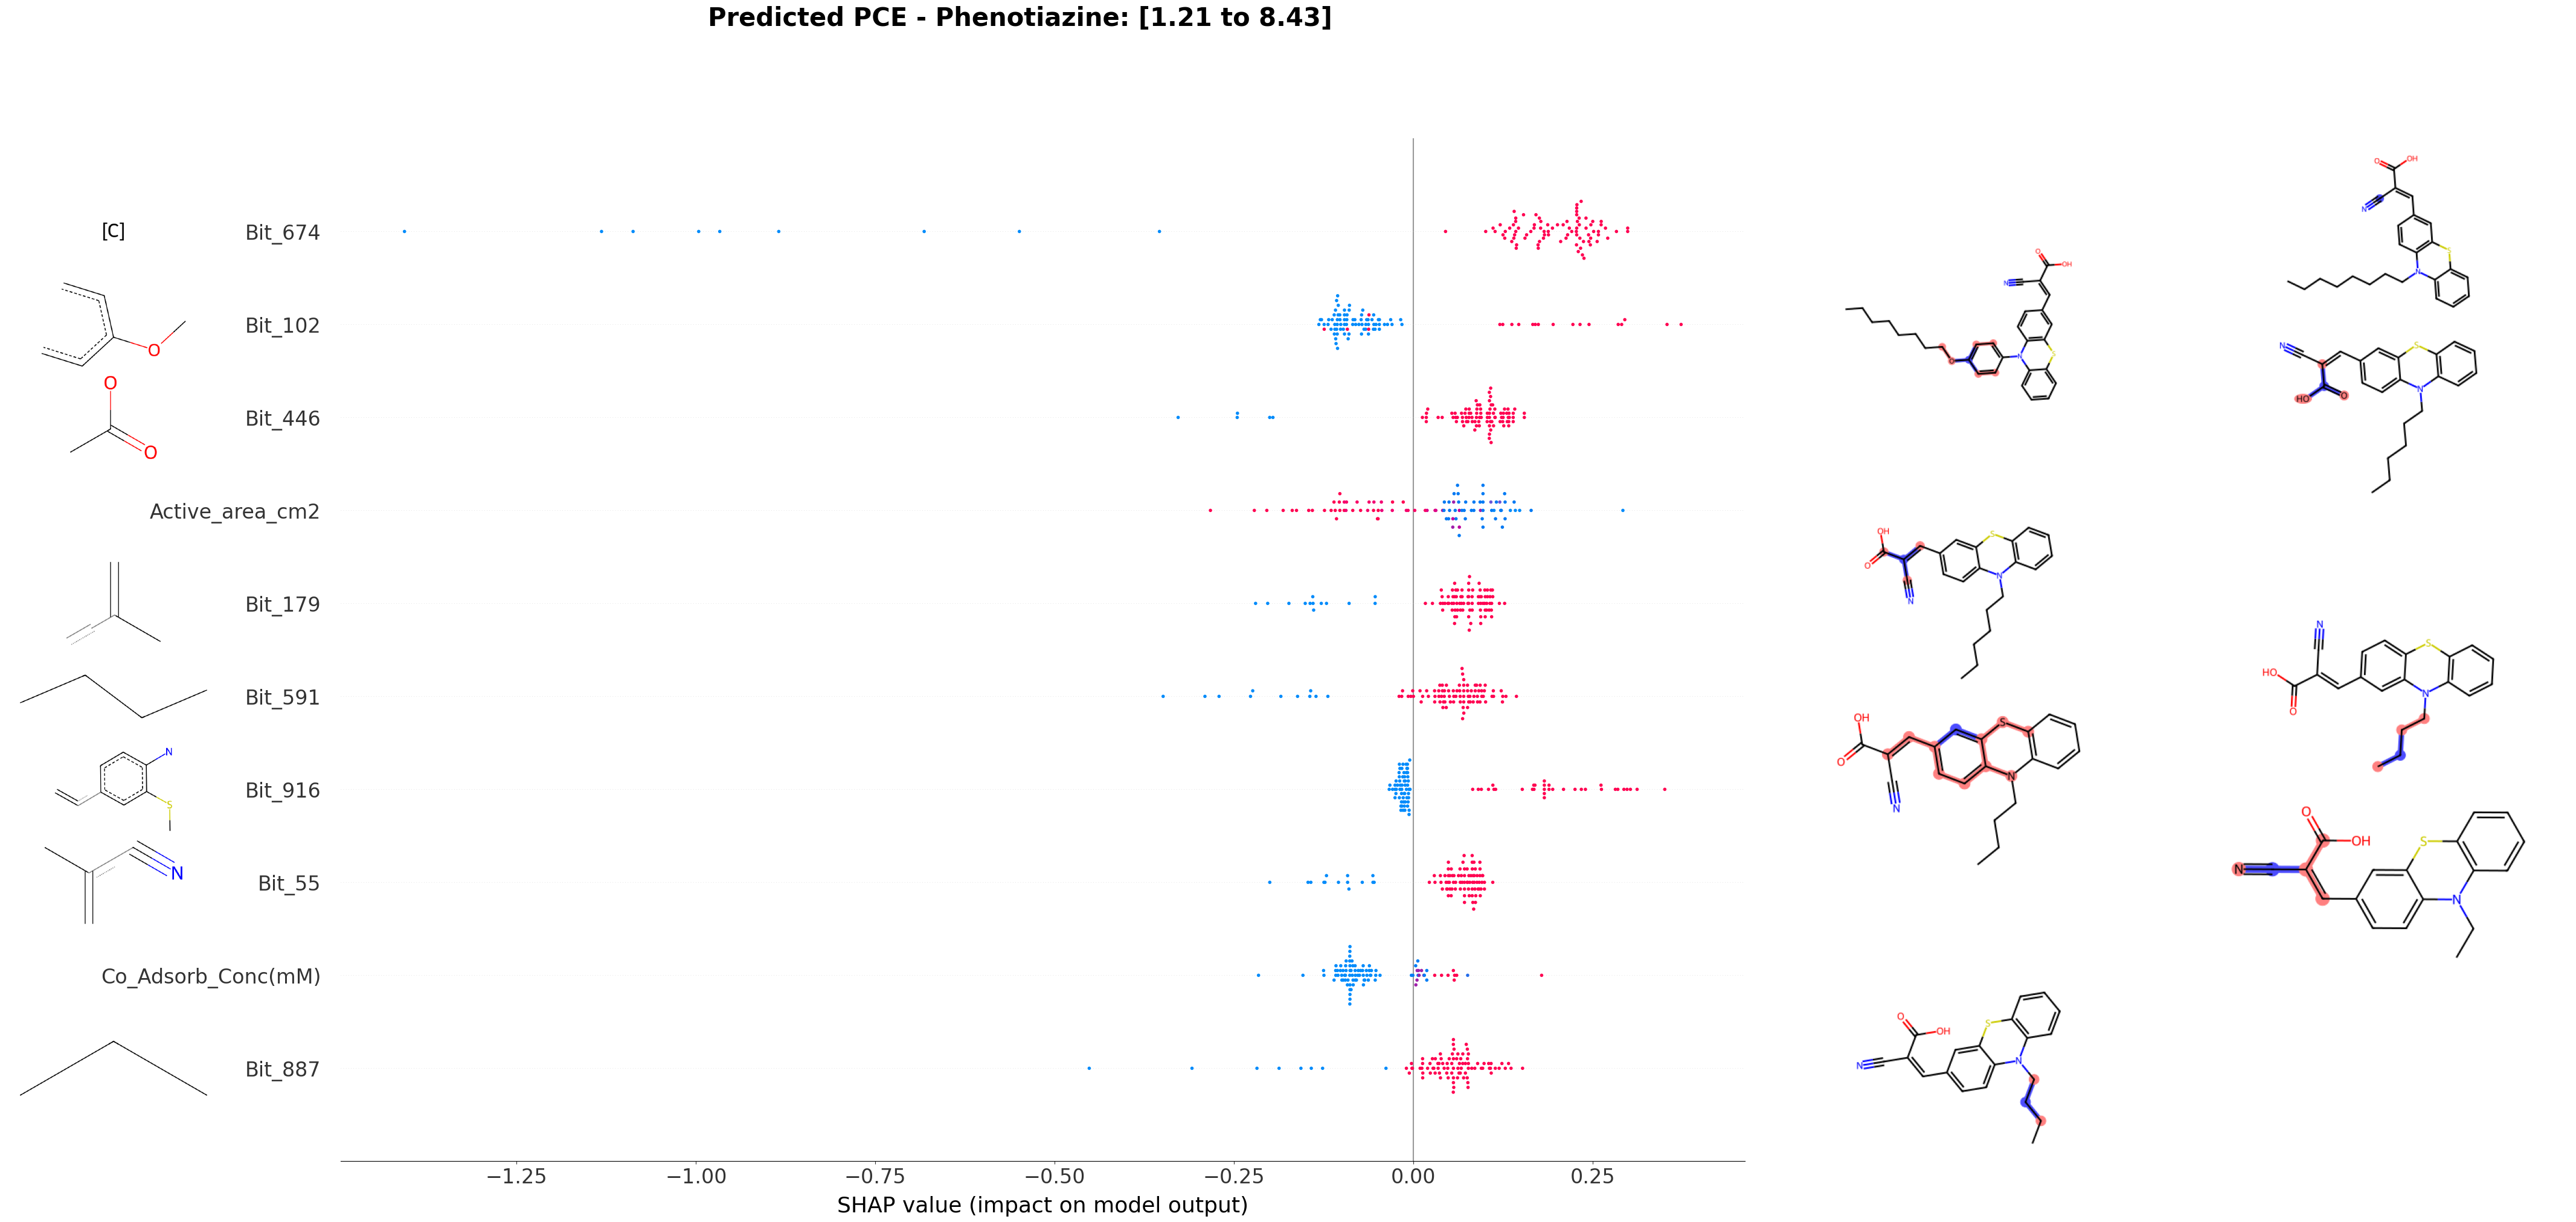

In [149]:
explain.shap_mol_fp(explanation=expl_tpa,
            X_test=X_test_tpa, 
            P_test=P_test_tpa, 
            title="Predicted PCE - Phenotiazine", 
            smiles_df=smiles_df,
            plot_type='dot', 
            left=-1550,
            right=650,
            max_display=10
)

c:\Users\anamj\Documents\DSSCDB_HS\DSSCDB\model_explain_functions.py:327: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


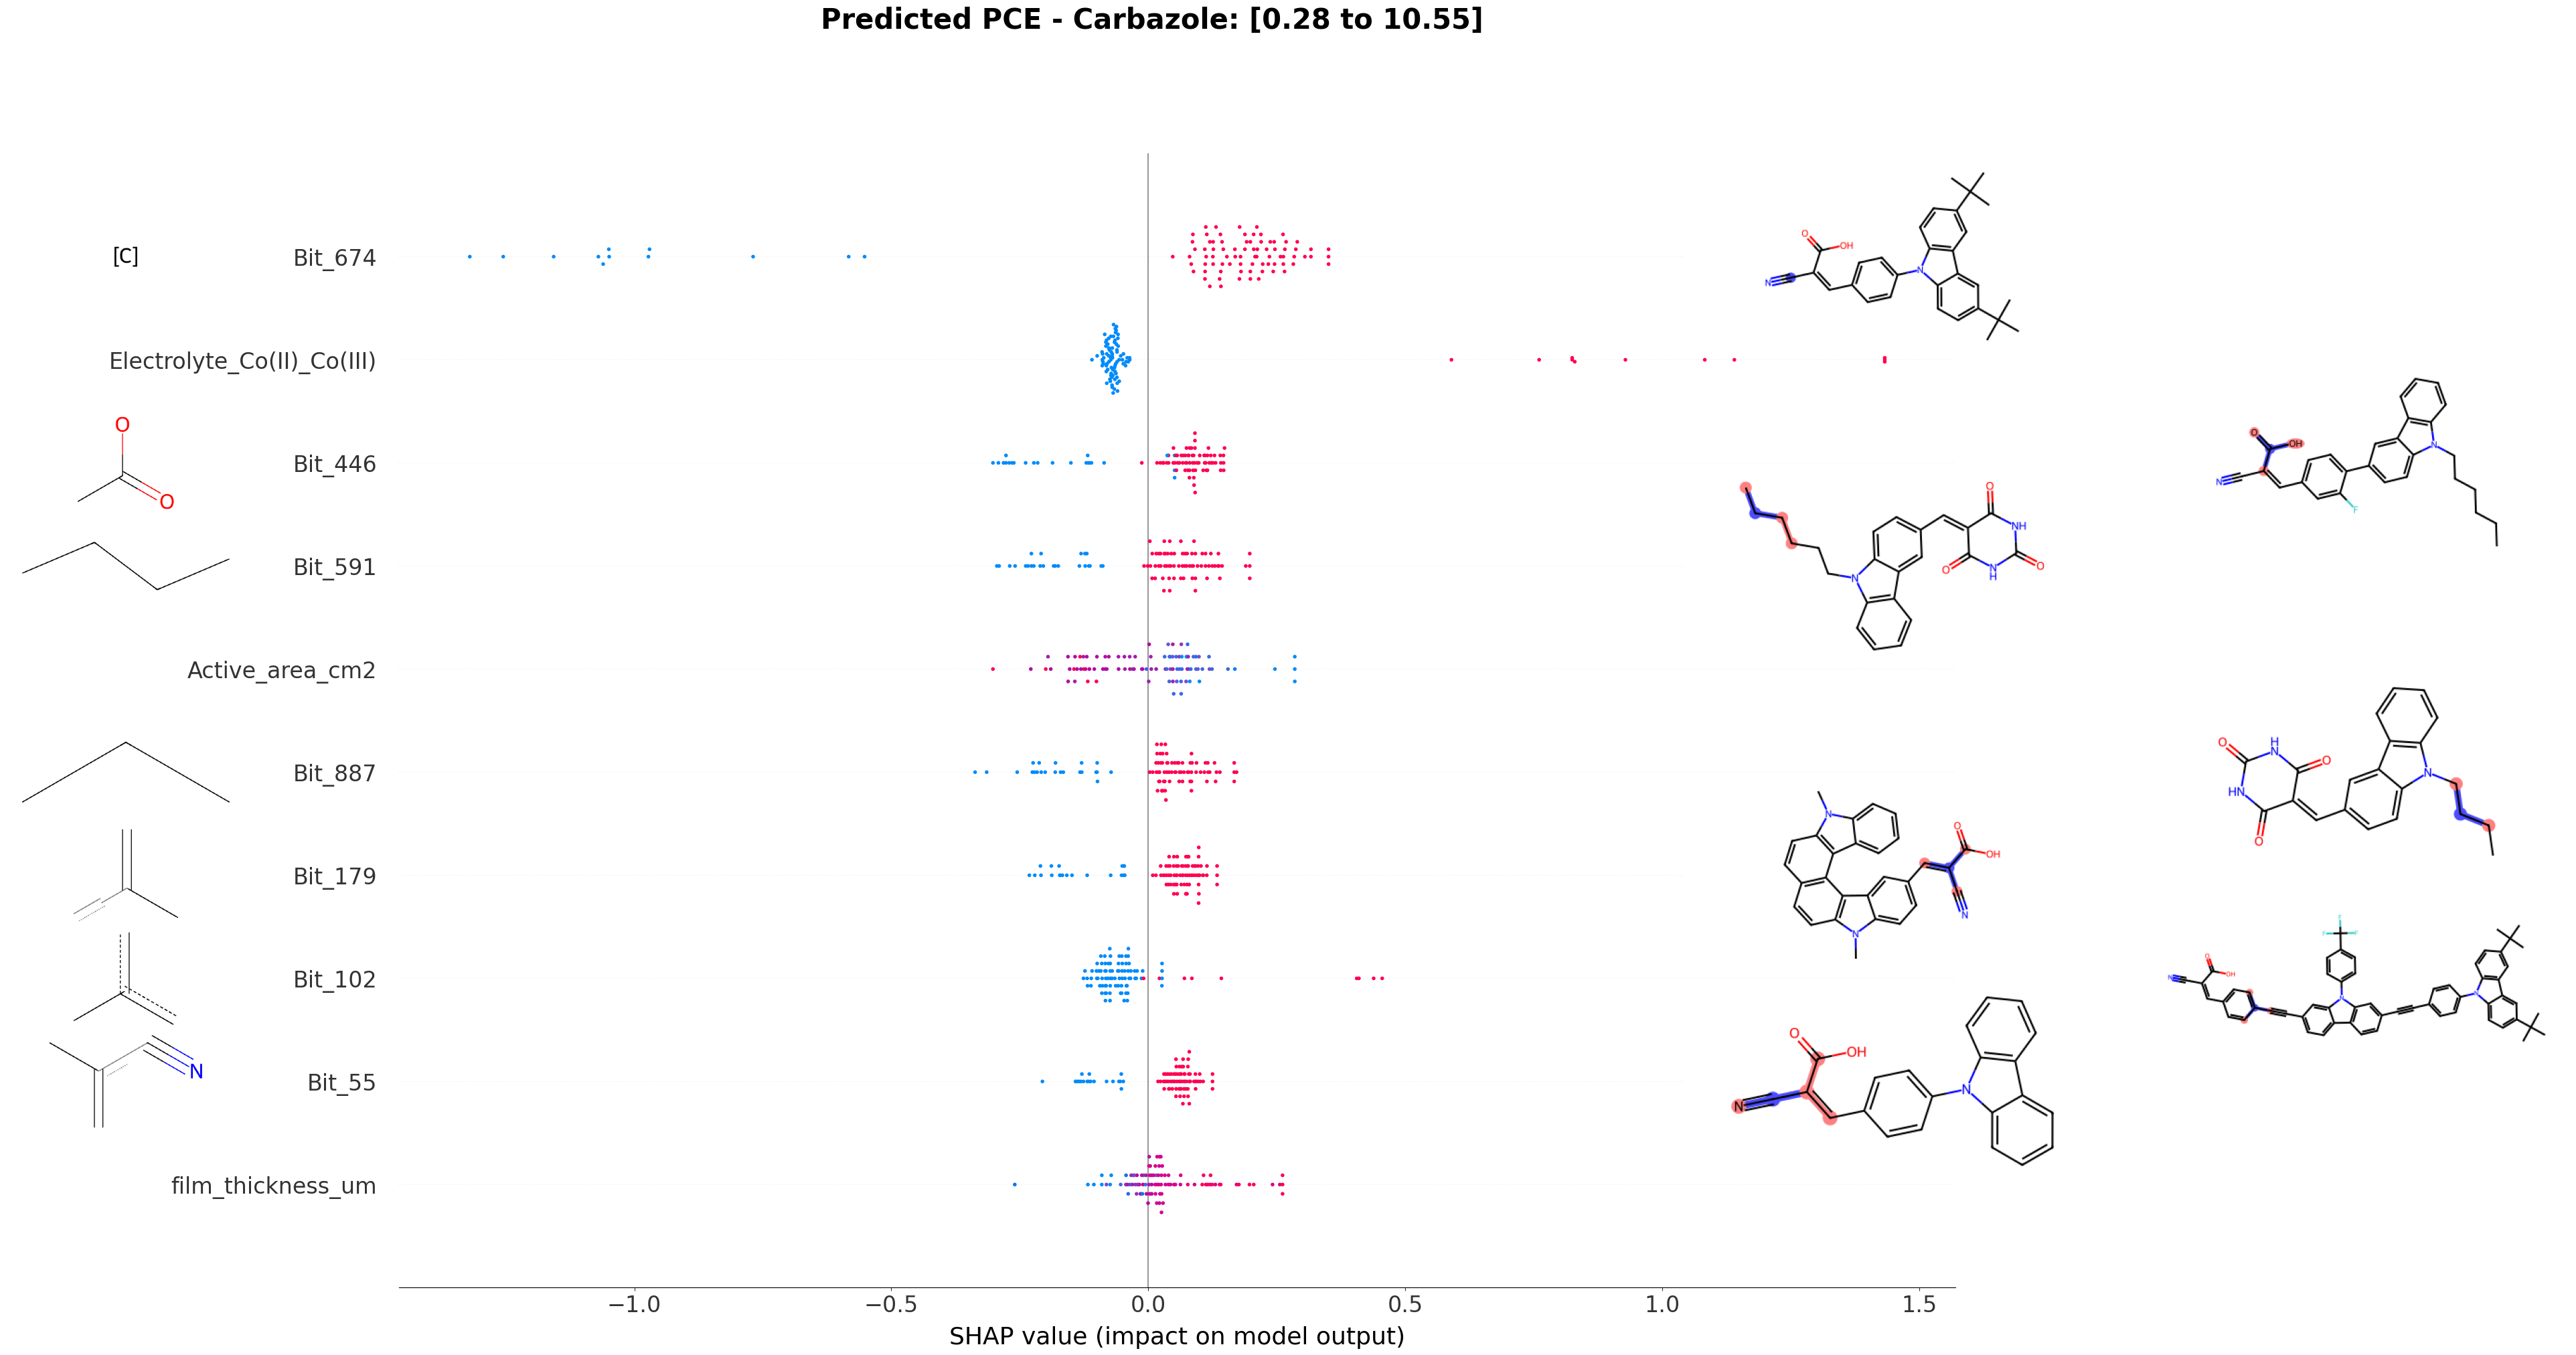

In [152]:
# 1) boolean mask (aligned to X_test’s order)
mask_tpa = out['primary_family'].eq('carbazole').to_numpy()

# 2) subset everything consistently
X_test_tpa = X_test.loc[mask_tpa]
P_test_tpa = P_test.loc[mask_tpa]
smiles_tpa = smiles_df.loc[mask_tpa]

# 3) SHAP Explanation supports boolean masks (positional)
expl_tpa = explanation[mask_tpa]

explain.shap_mol_fp(explanation=expl_tpa,
            X_test=X_test_tpa, 
            P_test=P_test_tpa, 
            title="Predicted PCE - Carbazole", 
            smiles_df=smiles_df,
            plot_type='dot', 
            left=-1100,
            right=800,
            max_display=10
)

c:\Users\anamj\Documents\DSSCDB_HS\DSSCDB\model_explain_functions.py:327: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


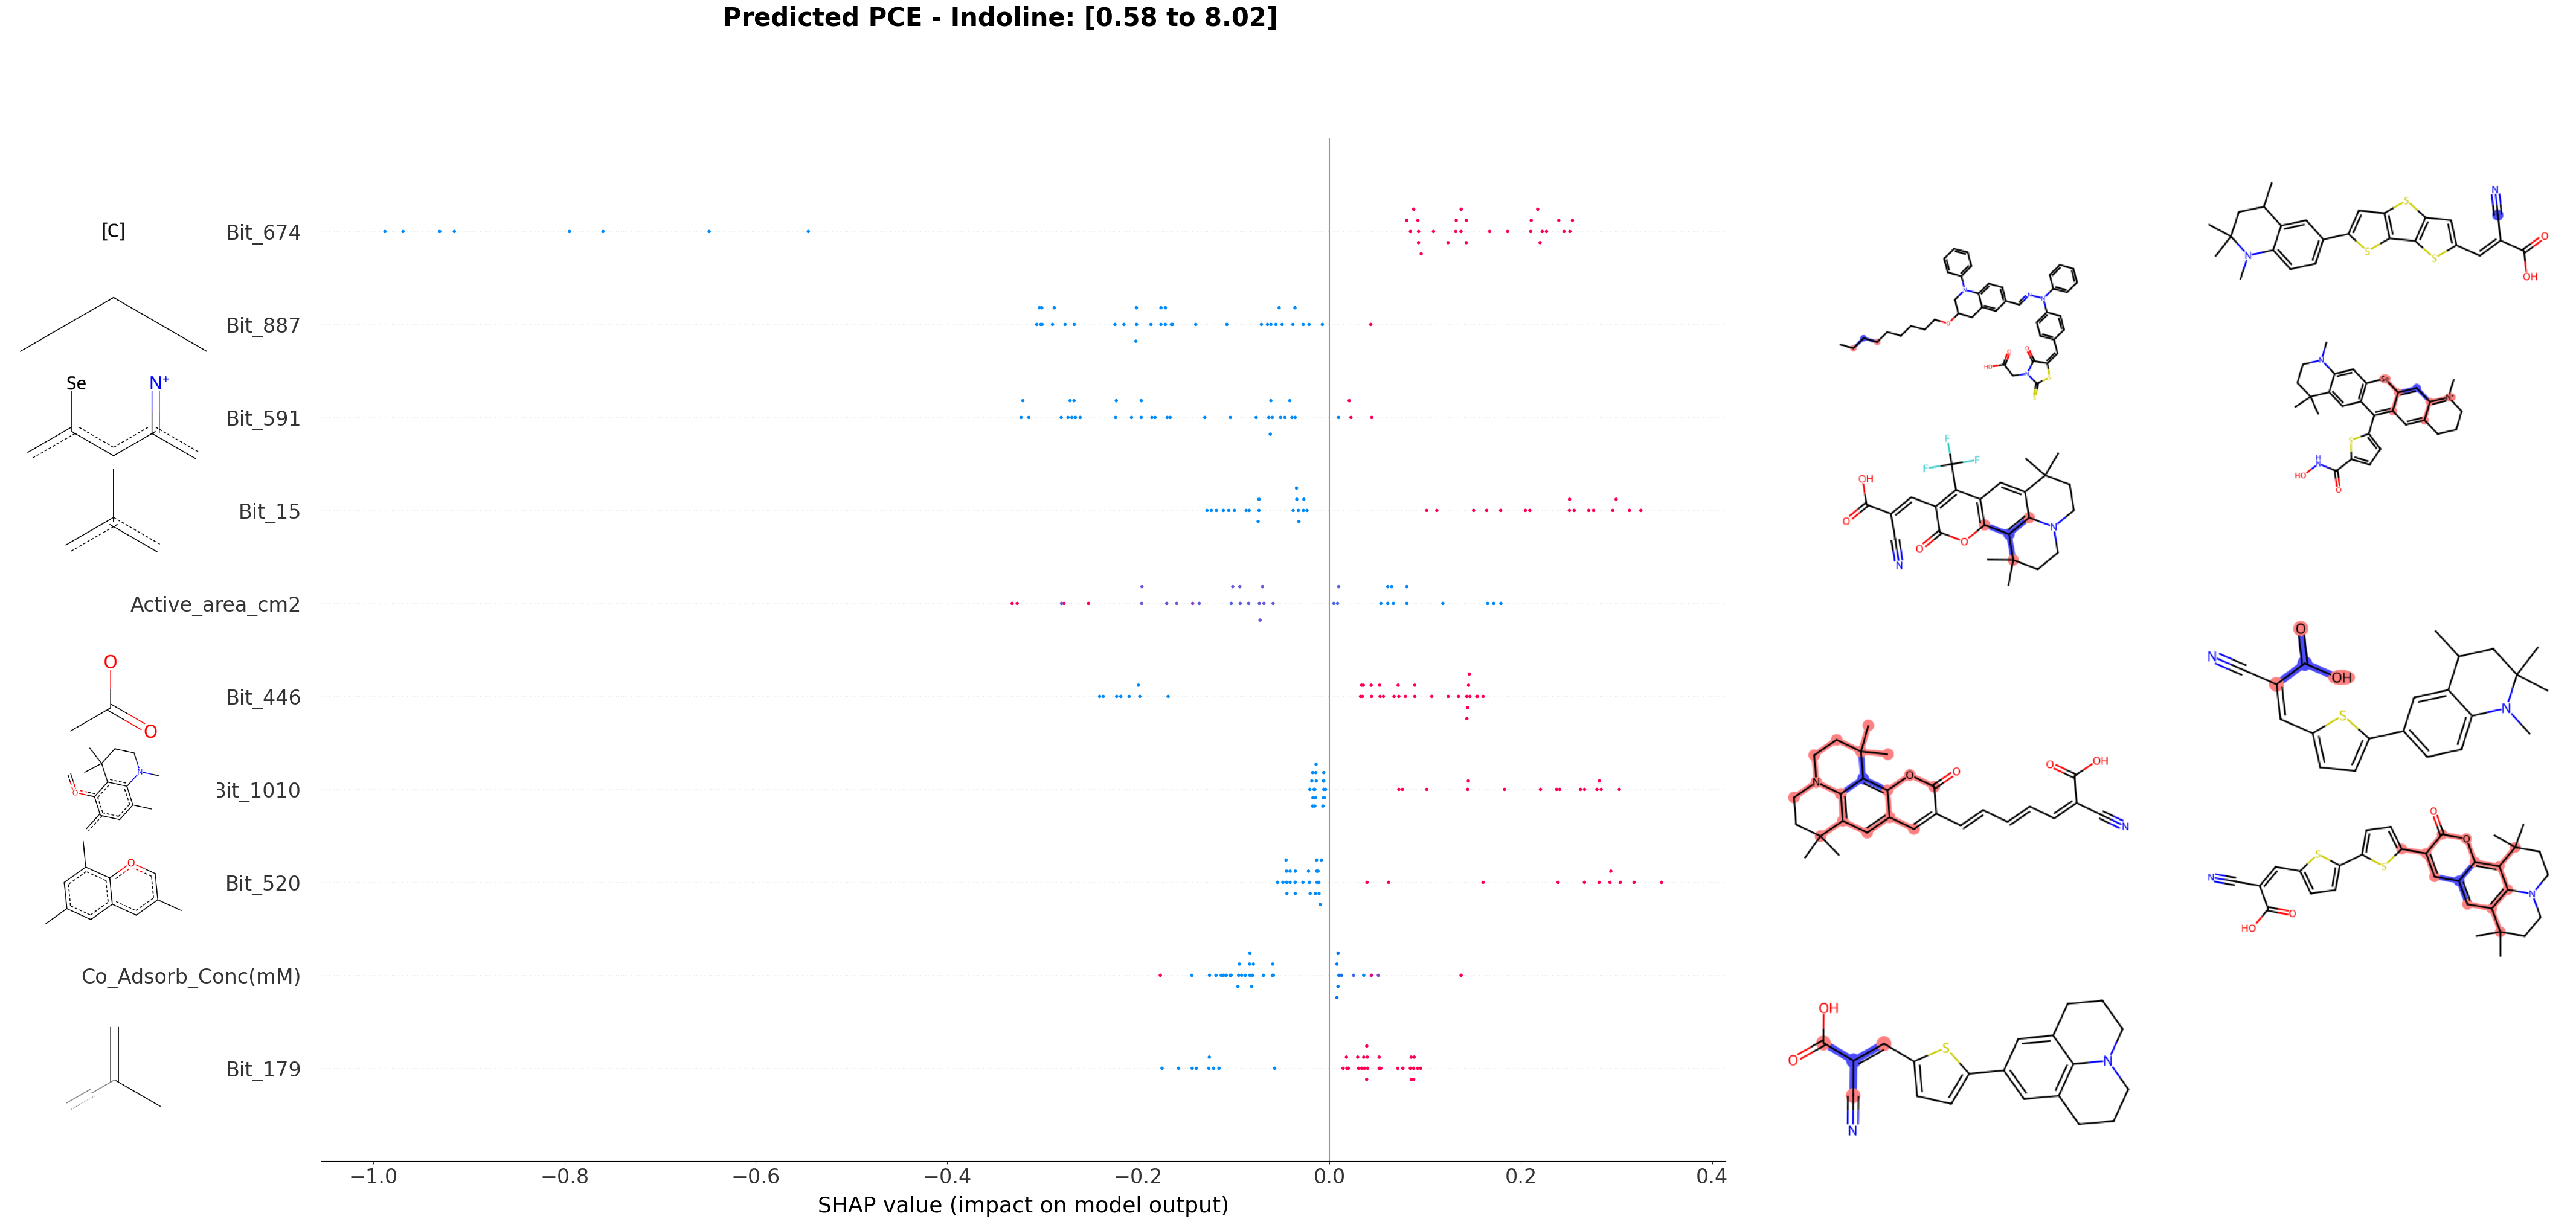

In [156]:
# 1) boolean mask (aligned to X_test’s order)
mask_tpa = out['primary_family'].eq('indoline').to_numpy()

# 2) subset everything consistently
X_test_tpa = X_test.loc[mask_tpa]
P_test_tpa = P_test.loc[mask_tpa]
smiles_tpa = smiles_df.loc[mask_tpa]

# 3) SHAP Explanation supports boolean masks (positional)
expl_tpa = explanation[mask_tpa]

explain.shap_mol_fp(explanation=expl_tpa,
            X_test=X_test_tpa, 
            P_test=P_test_tpa, 
            title="Predicted PCE - Indoline", 
            smiles_df=smiles_df,
            plot_type='dot',
            left=-1450,
            right=750, 
            max_display=10
)

c:\Users\anamj\Documents\DSSCDB_HS\DSSCDB\model_explain_functions.py:327: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


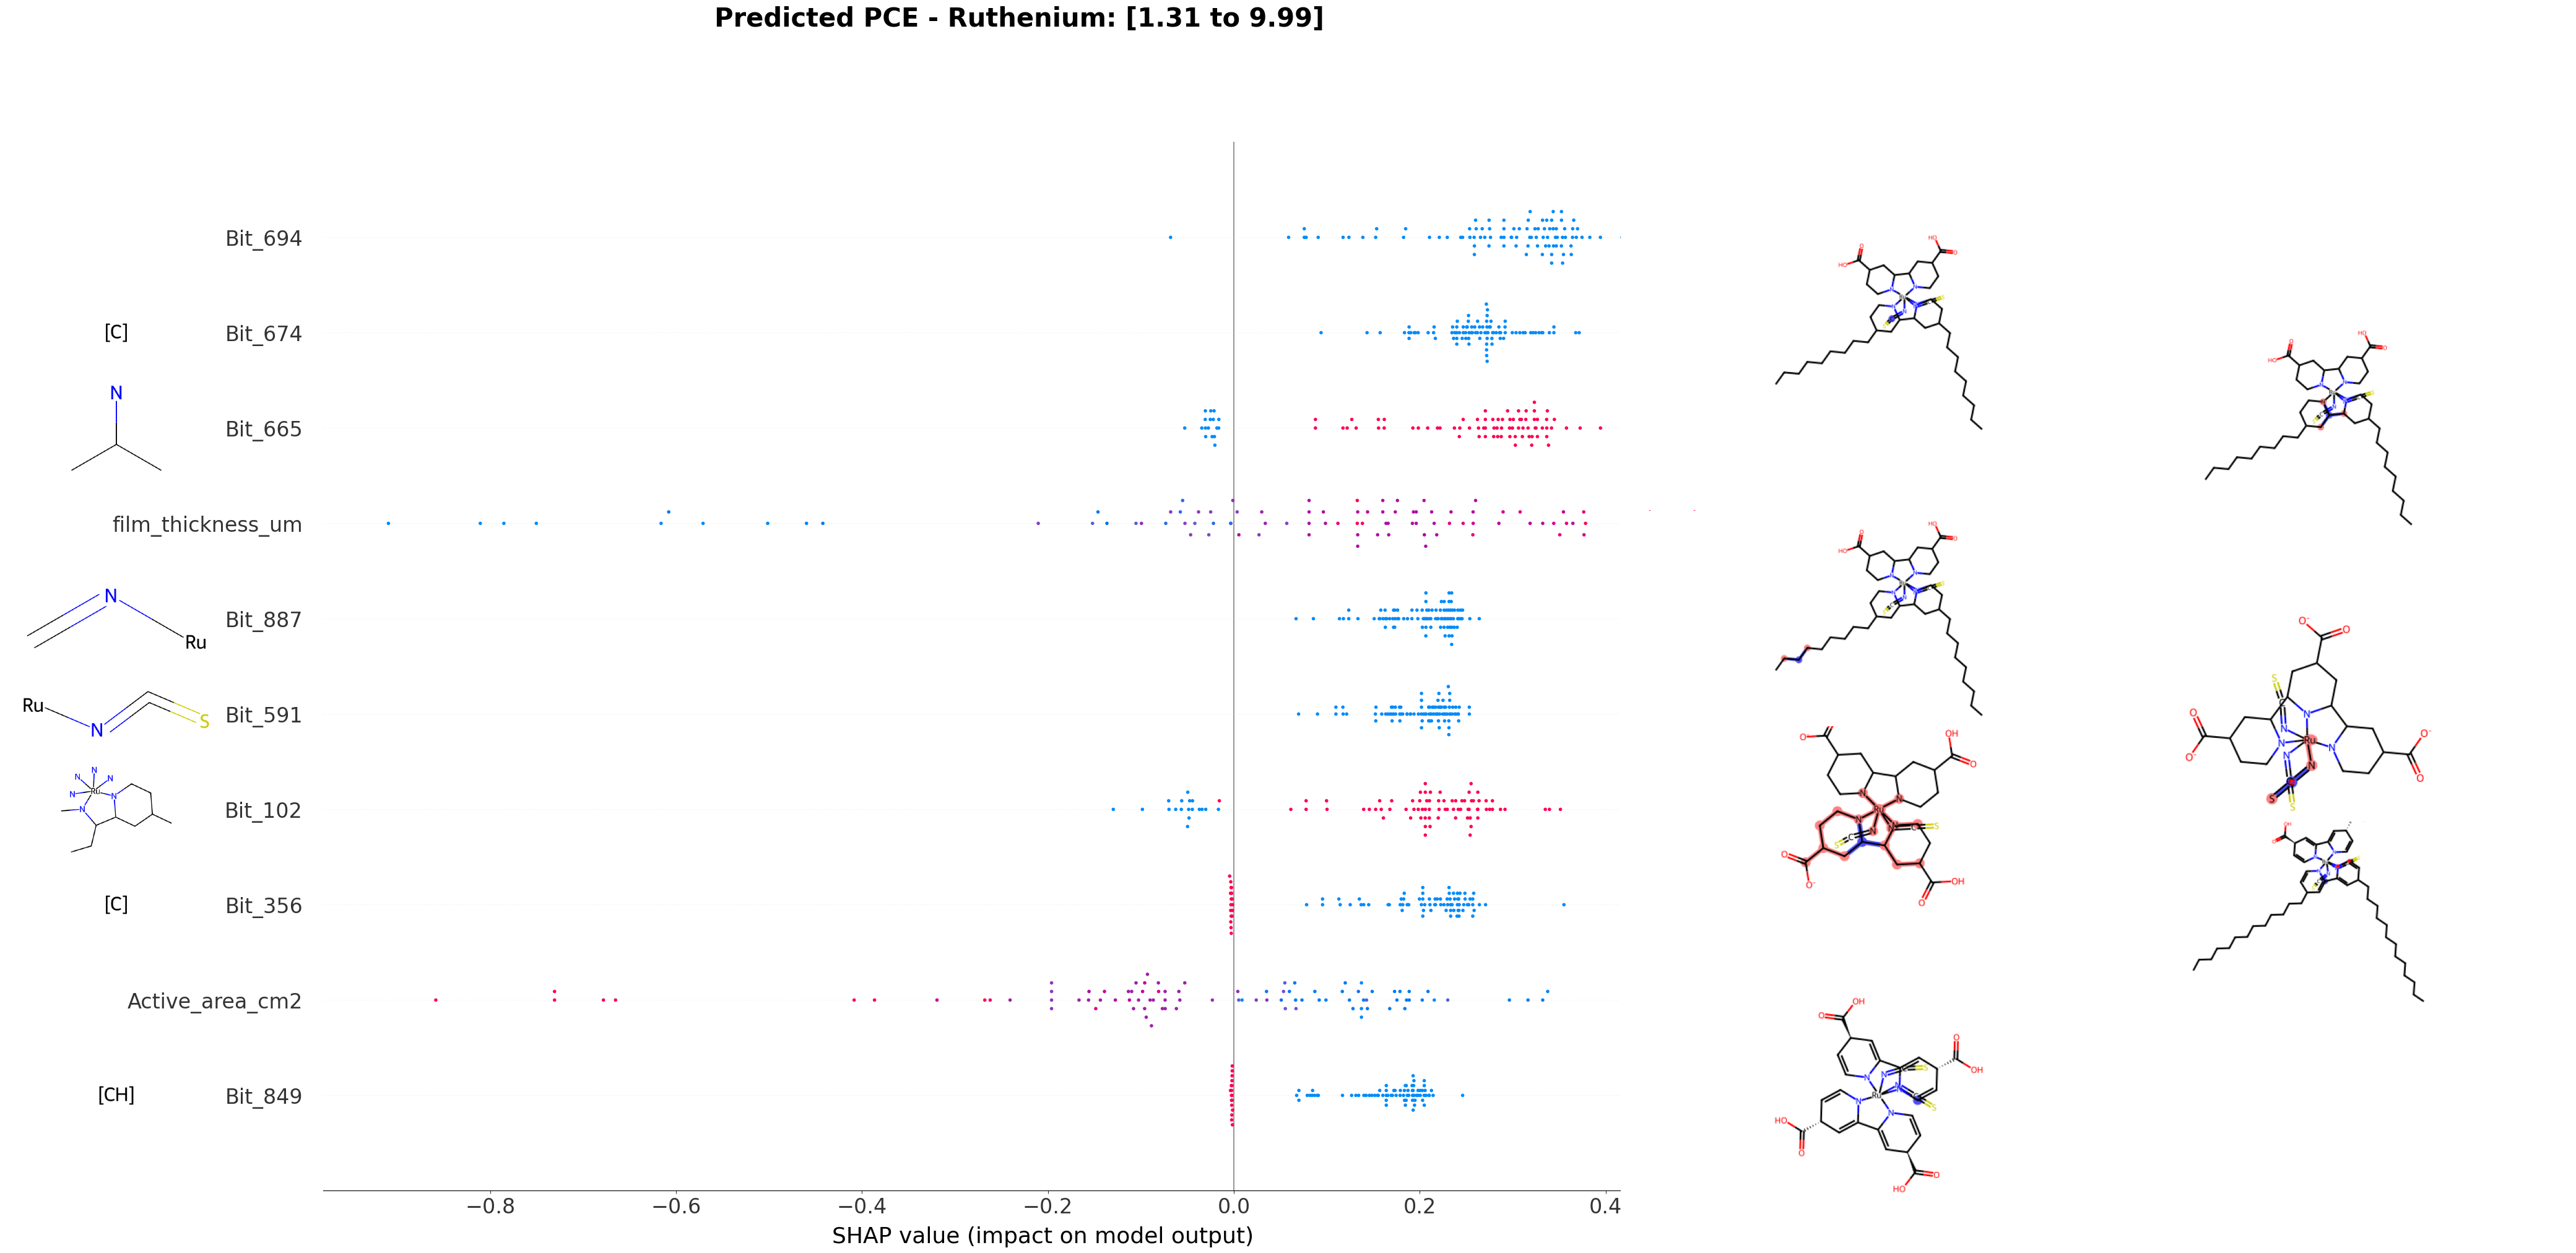

In [165]:
# 1) boolean mask (aligned to X_test’s order)
mask_tpa = out['primary_family'].eq('ruthenium').to_numpy()

# 2) subset everything consistently
X_test_tpa = X_test.loc[mask_tpa]
P_test_tpa = P_test.loc[mask_tpa]
smiles_tpa = smiles_df.loc[mask_tpa]

# 3) SHAP Explanation supports boolean masks (positional)
expl_tpa = explanation[mask_tpa]

explain.shap_mol_fp(explanation=expl_tpa,
            X_test=X_test_tpa, 
            P_test=P_test_tpa, 
            title="Predicted PCE - Ruthenium", 
            smiles_df=smiles_df,
            plot_type='dot',
            left=-1300,
            right=750, 
            max_display=10
)